# Import

In [1]:
from scipy.io import loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from mapd import Trial, Table, Sinq
import h5py
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib.colors as mcolors
import seaborn as sns

import plotly.express as px
from collections import defaultdict
import glob


import pickle
%load_ext autoreload
%autoreload 2
%matplotlib widget

def refresh_table_addons():
    import importlib
    import mapd.table_plotters as tps
    import mapd.table_scalars as tbs
    importlib.reload(tps)
    importlib.reload(tbs)

    for name in dir(tps):
        if name.startswith('_'):
            continue
        attr = getattr(tps, name)
        setattr(Table, name[len("plot_"):], attr)
    
    for name in dir(tbs):
        if name.startswith('_'):
            continue
        if name.startswith('compute_'):
            attr = getattr(tbs, name)
            setattr(Table, name[len("compute_"):], attr)

# Sinq2 

In [2]:
sinq2 = Sinq(sinqname='Fig2_learners')
print(sinq2.__repr__())
sinq2.df

Found data directory: D:\Data
Sinq(Fig2_learners, 18 rows x 29 params): 0 empties; ['210302_F1_C2', '210405_F1_C1', '210604_F1_C1', '210903_F3_C1', '210915_F1_C1', '210917_F2_C1', '250227_F2_C1', '250227_F3_C1', '250228_F2_C1', '250304_F3_C1', '250425_F1_C1', '250506_F2_C1', '250514_F1_C1', '250923_F1_C1', '250923_F2_C1', '250924_F1_C1', '250924_F2_C1', '250925_F1_C1'] x ['parquet', 'Table', 'genotype', 'duration', 'rms_velocity', 'outcome_fractions_no_as_no_mv', 'outcome_fractions_as_off', 'outcome_fractions_rest', 'outcome_fractions_no_as_mv', 'outcome_fractions_probe', 'outcome_fractions_as_off_late', 'outcome_fractions_timeout_fail', 'outcome_fractions_timeout', 'outcome_fractions_info', 'lo_state_median_position', 'hi_state_median_position', 'hi_lo_shift', 'hi_state_on_target', 'lo_state_on_target', 'num_trials', 'blue_fraction', 'blue_toggle_fraction', 'most_common_fiberLED', 'lo_target_off_state', 'hi_target_off_state', 'probe_positive_effort', 'successes', 'hard_successes', 'ho

,parquet,Table,genotype,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,outcome_fractions_rest,outcome_fractions_no_as_mv,outcome_fractions_probe,...,num_trials,blue_fraction,blue_toggle_fraction,most_common_fiberLED,lo_target_off_state,hi_target_off_state,probe_positive_effort,successes,hard_successes,holding_cost
210302_F1_C2,LEDFlashWithPiezoCueControl_210302_F1_C2_Table...,None,Hot-Cell-Gal4 (test),6836.72718,32982.968041,0.561250,0.173750,0.118750,0.111250,0.000000,...,800.0,1.000000,0.000000,625_red,0.055824,0.082934,8.684294e+05,78.0,37.0,9.147350e+06
210405_F1_C1,LEDFlashWithPiezoCueControl_210405_F1_C1_Table...,None,Hot-Cell-LexA_Chr;81A06_pJFRC7,6582.81488,34006.653998,0.462382,0.087774,0.112853,0.105016,0.000000,...,638.0,1.000000,0.171378,625_red,0.145846,0.206347,1.349486e+06,34.0,13.0,1.307052e+07
210604_F1_C1,LEDFlashWithPiezoCueControl_210604_F1_C1_Table...,None,Hot-Cell-LexA_Chr;35c09_pJFRC7,3685.79266,44418.935879,0.565714,0.102857,0.120000,0.085714,0.000000,...,350.0,1.000000,0.107143,625_red,0.138731,0.180145,1.728146e+06,15.0,9.0,6.519351e+06
210903_F3_C1,LEDFlashTriggerPiezoControl_210903_F3_C1_Table...,None,Hot-Cell-LexA_Chr;35C09_pJFRC7,6303.51030,45596.022785,0.426667,0.131667,0.120000,0.086667,0.000000,...,600.0,1.000000,0.204545,625_red,0.125386,0.072073,1.898442e+06,37.0,14.0,1.363618e+07
210915_F1_C1,LEDFlashTriggerPiezoControl_210915_F1_C1_Table...,None,Hot-Cell-LexA_Chr;78E05_pJFRC7,5857.48988,45659.433547,0.410463,0.084507,0.120724,0.078471,0.000000,...,497.0,1.000000,0.237986,625_red,0.109020,0.279235,2.327835e+06,27.0,12.0,1.325873e+07
210917_F2_C1,LEDFlashTriggerPiezoControl_210917_F2_C1_Table...,None,Hot-Cell-LexA_Chr;31H05_pJFRC7,5780.00094,74683.629443,0.315498,0.276753,0.121771,0.127306,0.000000,...,542.0,1.000000,0.182773,625_red,0.111971,0.241052,4.262578e+06,50.0,19.0,1.208222e+07
250227_F2_C1,LEDFlashTriggerPiezoControl_250227_F2_C1_Table...,None,SS61350_pJFRC7,7224.62008,236730.246194,0.478431,0.315033,0.117647,0.054902,0.014379,...,765.0,0.666667,1.000000,epi_only,0.115984,0.042458,7.757883e+06,44.0,29.0,1.284016e+07
250227_F3_C1,LEDFlashTriggerPiezoControl_250227_F3_C1_Table...,None,SS61350_pJFRC7,6078.90756,392467.613033,0.360502,0.333856,0.206897,0.056426,0.012539,...,638.0,1.000000,1.000000,epi_only,0.048098,0.169664,1.715732e+07,27.0,12.0,1.004275e+07
250228_F2_C1,LEDFlashTriggerPiezoControl_250228_F2_C1_Table...,None,SS61350_pJFRC7,5978.05628,117477.458152,0.626374,0.167975,0.102041,0.043956,0.015699,...,637.0,0.000000,1.000000,epi_only,0.083723,0.101560,5.082797e+06,31.0,23.0,1.093529e+07
250304_F3_C1,LEDFlashTriggerPiezoControl_250304_F3_C1_Table...,None,SS61350_pJFRC7,13404.06094,190728.766293,0.655862,0.171034,0.100000,0.042759,0.017241,...,1450.0,1.000000,1.000000,epi_only,0.069873,0.041706,1.352463e+07,75.0,45.0,2.341512e+07


# Figure 2A - outcomes, how flies solve


In [ ]:
# Only do this for new ones

for id in sinq2.df.index:
    folder_path = f'./Figure2/{id}'
    if os.path.exists(folder_path):
        print(f"Folder '{folder_path}' exists. Continuing...")
        continue
    else:
        print(f"Folder '{folder_path}' does not exist.")


    T = sinq2.restore_table(id)
    T.extract_trial_properties()
    fig,ax = T.plot_outcomes(savefig=True,format='png',fig_dir=f'./Figure2/{id}')

    T.compute_trial_method('prestim_holding_cost')
    fig,ax = T.plot_trial_computations('prestim_holding_cost',savefig=True,fig_dir=f'./Figure2/{id}')

    T.compute_trial_method('prestim_v_rms')
    fig,ax = T.plot_trial_computations('prestim_v_rms',savefig=True,fig_dir=f'./Figure2/{id}')

    T.compute_trial_method('probe_effort')
    fig,ax = T.plot_trial_computations('probe_effort',savefig=True,fig_dir=f'./Figure2/{id}')

    T.compute_trial_method('probe_positive_effort')
    fig,ax = T.plot_trial_computations('probe_positive_effort',savefig=True,fig_dir=f'./Figure2/{id}')

    T.compute_trial_method('probe_rms_velocity')
    fig,ax = T.plot_trial_computations('probe_rms_velocity',savefig=True,fig_dir=f'./Figure2/{id}')
    display(fig)


plt.close('all')

# Functions

In [ ]:
k_spring_constant = 0.0829 #uN/um

def probe_velocity(t,p):
        x = p.squeeze()
        t = t.squeeze()
        v = np.gradient(x, t)
        return v

def probe_rms_velocity(t,p):
    """Weights faster movements more"""
    v = probe_velocity(t,p)
    rms_vigor = np.sqrt(np.mean(v**2))
    return rms_vigor

# def probe_jerk_energy(self):
#     """A measure of effort in motor control"""
#     ds_time = self.time[self.downsample_probe]
#     jerk = np.gradient(self.probe_acceleration(), ds_time)
#     jerk_energy = np.sum(jerk**2) * np.diff(ds_time[2:3])
#     return jerk_energy

def probe_power(t,p):
    v = probe_velocity(t,p)
    power = k_spring_constant * p * v
    return power

def probe_work(t,p):
    """Work Done Against the Spring"""
    power = probe_power(t,p)
    work = np.trapezoid(power,t)
    return work

def probe_positive_effort(t,p):
    '''Assumes p is never negative'''
    vel = probe_velocity(t,p)
    pos_vel = np.clip(vel, a_min=0, a_max=None)
    power = k_spring_constant * p * pos_vel
    effort = np.trapezoid(np.clip(power, a_min=0, a_max=None), t)
    return effort

def make_successful_trial_products(T:Table = None,fig_dir = './Figure2'):
    output_directory = f'./Figure2/{T.dfc}/successes_{T.dfc}'
    export_path = os.path.join(f'./Figure2/{T.dfc}','exports')

    T.find_successful_trials()
    trials = T.df.loc[:,['Trial','success','hard_success','soft_success','pyasState']].copy()
    trials['next_trial'] = trials['Trial'].shift(-1)
    trials = trials.loc[trials['success']]
    print(trials.shape[0])

    trials = trials.loc[trials['hard_success']]
    print(trials.shape[0])

    trials['fig'] = pd.NA
    trials['v_rms'] = pd.NA
    trials['effort'] = pd.NA

    for t_num in trials.index:
        fig = Figure(figsize=(6, 6), dpi=200)
        canvas = FigureCanvas(fig)
        ax = fig.add_subplot(111)

        # success_index = -1
        # success_index = success_index+1
        # row = trials.iloc[success_index]
        row = trials.loc[t_num]
        trial1 = row['Trial']
        trial2 = row['next_trial']

        probe = []
        time = []
        for trial in [trial1,trial2]:
            pps = (trial.probe_position - trial.probeZero).squeeze()
            probe.append(pps[trial.downsample_probe])
            time.append(trial.time[trial.downsample_probe].squeeze())

        dT = np.diff([time[0][0],time[0][-1]])
        dt = np.diff([time[0][0],time[0][1]])
        time[1] = time[1]+dT+dt
        t = np.concat(time) #.ravel()
        p = np.concat(probe) #.ravel()

        start_time = trial1.as_duration
        start_idx = np.where(t>start_time)[0][0]

        # end_pos = probe[1][(time[1]>=0) & (time[1]<1)].mean()
        end_pos = (trial2.probe_position[(trial2.time>=0) & (trial2.time<1)].mean() - trial2.probeZero)
        # print(end_pos)
        end_idx = np.where(p<end_pos)[0][-1]
        end_time = t[end_idx]
        search_time = t[start_idx:end_idx]
        search = p[start_idx:end_idx]

        # v = probe_velocity(search_time,search)
        v_rms = probe_rms_velocity(search_time,search)
        search_power = probe_power(search_time,-search)
        search_effort = probe_positive_effort(search_time,-search)

        info_str = f'v_rms = {v_rms:.1f}; effort = {search_effort:.1f}'

        T.plot_some_probe_groups(T.df.loc[row.name:row.name+2,:].index,ax=ax) #,force_pos=True)
        x_lims = ax.get_xlim()
        y_lims = ax.get_ylim()
        ax.plot(x_lims,end_pos*np.array([1,1]))
        ax.plot(search_time,search)
        scaled_power = search_power/np.max((np.abs([search_power.max(),search_power.min()])))
        # ax.plot(search_time,-scaled_power)
        
        def tpos(lims,scalar=.9):
            return np.diff(lims)*scalar+lims[0]
        ax.text(tpos(x_lims,.6),tpos(y_lims),info_str)

        trials.loc[t_num,'fig'] = fig
        trials.loc[t_num,'v_rms'] = v_rms
        trials.loc[t_num,'effort'] = search_effort

    for trn in trials.index:
        trials.loc[trn,'fig'].savefig(f'{output_directory}/trial_{trn}.svg')

    cats = trials.index
    n = len(trials)
    palette = sns.color_palette("Set2", n)
    color_map = dict(zip(cats, palette))

    # Reuse proj_df and color_map from above
    export_df = trials[['success','hard_success','soft_success','pyasState','v_rms','effort']] # trial_number	Trial	success	hard_success	soft_success	pyasState	next_trial	fig	v_rms	effort
    export_df = export_df.reset_index()
    export_df['dfc'] = T.dfc
    pklname = f'{export_path}/{T.dfc}_{T.genotype}_success_df.pkl'
    print(pklname)
    export_df.to_pickle(pklname)
    
    plot_df = trials.reset_index()

    # Convert seaborn/matplotlib colors to hex for plotly
    # color_map = dict(zip(cats, palette))
    color_map_hex = {g: mcolors.to_hex(c) for g, c in color_map.items()}

    fig = px.scatter(
        plot_df,
        x="v_rms", y="effort", 
        color="pyasState",
        color_discrete_map=color_map_hex,
        hover_data=["trial_number",],
        title="v_rms vs. effort"
    )
    fig.update_traces(marker=dict(size=5, opacity=0.9))
    fig.update_layout(
        legend_title_text="trial_number",
        scene=dict(
            xaxis_title=f"v_rms",
            yaxis_title=f"effort",
        )
    )

    fig.update_layout(
        width=1100, height=850,                    # << size here
        margin=dict(l=60, r=260, t=70, b=50),      # leave space for a tall legend
        font=dict(size=16),
        legend=dict(y=1, x=1.02, yanchor="top"),   # legend outside
        scene=dict(
            xaxis=dict(tickfont=dict(size=12)),
            yaxis=dict(tickfont=dict(size=12)),
            zaxis=dict(tickfont=dict(size=12)),
        ),
        hoverlabel=dict(font_size=14)
    )

    output_directory = f'{fig_dir}/{T.dfc}'
    os.makedirs(output_directory, exist_ok=True)

    fig.write_image(f'{output_directory}/success_effort_v_rms_{T.dfc}.png')


def fold_blocks(T:Table = None,fig_dir:str = './Figure2',norm:bool = False):
    output_directory = f'{fig_dir}/{T.dfc}/successes_{T.dfc}'
    export_path = f'{fig_dir}/{T.dfc}/exports'

    df = T.df.loc[T.df.index>100,['pyasState','op_cnd_blocks','as_outcome','success','as_duration']]

    df = df.copy()
    df['block_pair'] = (df['op_cnd_blocks'] - 1) // 2 + 1   # pair_id 1..14

    # 2. Align trials relative to the start of each block
    df['trial_in_block'] = df.groupby('op_cnd_blocks').cumcount()
    df['probe_as'] = (df['as_duration']>0) & (df['as_outcome']=='probe')
    df = df.loc[df.trial_in_block<50]
    
    outcome_counts = (
        df.groupby(['pyasState', 'trial_in_block', 'as_outcome'])
        .size()
        .unstack(fill_value=0)
    )
    outcome_counts = outcome_counts.loc[['hi','lo']]
    outcome_counts['max_cnts'] = outcome_counts.sum(axis=1,skipna=True)
    outcome_counts['as_off'] = outcome_counts['as_off'] + outcome_counts['as_off_late']
    outcome_counts['no_as'] = outcome_counts['no_as_no_mv'] + outcome_counts['no_as_mv']
    outcome_counts['to'] = outcome_counts['timeout_fail'] + outcome_counts['timeout']

    success_counts = (
        df.groupby(['pyasState', 'trial_in_block', 'success'])
        .size()
        .unstack(fill_value=0)
    )
    success_counts = success_counts.loc[['hi','lo'],True]
    success_counts = success_counts.to_frame(name='success')
    outcome_counts['success'] = success_counts['success']

    probe_as_counts = (
        df.groupby(['pyasState', 'trial_in_block', 'probe_as'])
        .size()
        .unstack(fill_value=0)
    )
    probe_as_counts = probe_as_counts.loc[['hi','lo']]
    if not True in probe_as_counts.columns:
        probe_as_counts[True] = 0
    probe_as_counts = probe_as_counts.loc[['hi','lo'],True]
    probe_as_counts = probe_as_counts.to_frame(name='probe_as')
    outcome_counts['probe_as'] = probe_as_counts['probe_as']
    
    outcome_counts.to_pickle(path=f'{export_path}/folded_outcome_counts_{T.dfc}.pkl')

    # del fig
    plt.close('all')
    fig = Figure(figsize=(8,8))
    lines = defaultdict(dict)

    colors = {'hi': '#1f77b4', 
            'lo': '#d62728'}
    colors = {'as_off': "#169400", 
              'no_as': "#000cad",
              'no_as_mv': "#6068cb",
              'success': "#009480",
              'to': "#FF0000",
              'probe_as': "#FF30FC",
            }

    hi_x = outcome_counts.xs('hi', level='pyasState').index
    x = {'hi': hi_x,
        'lo': outcome_counts.xs('lo', level='pyasState').index + hi_x[-1] + 1}

    outcome_to_ax = {'as_off':1,
                    'no_as':2,
                    'no_as_mv':2,
                    'success':3,
                    'to':3,
                    'probe_as':3,}

    ax_ids = sorted(set(outcome_to_ax.values()))
    ax_id_to_ax = {}
    for i, ax_id in enumerate(ax_ids, start=1):
        # nrows = len(ax_ids), ncols = 1, index = i
        ax_id_to_ax[ax_id] = fig.add_subplot(len(ax_ids), 1, i)

    for outcome in outcome_to_ax.keys():
        for st in ['hi','lo']:
            ax = ax_id_to_ax[outcome_to_ax[outcome]]
            hi_y = outcome_counts.xs(st, level='pyasState').get(outcome)
            if norm:
                hi_y = hi_y / outcome_counts.xs(st, level='pyasState').get('max_cnts')

            lines[outcome][st], = ax.plot(
                        x[st], hi_y, label=f'{outcome} ({st})', linewidth=1, alpha=0.9, color=colors[outcome]
                    )
            if norm:
                ax.set_ylim([0, 1])
            else:
                ax.set_ylim([0, np.max(outcome_counts.xs(st, level='pyasState').get('max_cnts'))])

    ax_id_to_ax[1].set_ylabel('as_off')
    ax_id_to_ax[2].set_ylabel('no_as')
    ax_id_to_ax[3].set_ylabel('success')
    ax_id_to_ax[3].legend()

    output_directory = f'./Figure2/{T.dfc}'
    os.makedirs(output_directory, exist_ok=True)

    fig.savefig(f'{output_directory}/outcomes_over_blocks_{T.dfc}.svg')
    
    display(fig)

# Export v_rms vs effort, and AS_outcomes over folded blocks

In [ ]:
# for dfc in ['250304_F3_C1','250425_F1_C1']:
for dfc in sinq2.df.index:
    dfc_path = f'./Figure2/{dfc}'
    success_path = f'{dfc_path}/successes_{dfc}'
    export_path = os.path.join(f'./Figure2/{dfc}','exports')
    
    os.makedirs(dfc_path, exist_ok=True)
    os.makedirs(success_path, exist_ok=True)
    os.makedirs(export_path, exist_ok=True)
    
    table_chk_pnt = (not os.path.isfile(f'{dfc_path}/outcomes_over_blocks_{dfc}.svg') 
                 or not os.path.isfile(f'{export_path}/folded_outcome_counts_{dfc}.pkl') 
                 or not os.path.isfile(f'{export_path}/{dfc}_{sinq2.df.loc[dfc,'genotype']}_success_df.pkl'))

    if table_chk_pnt:    
        T = sinq2.restore_table(dfc)
        T.extract_trial_properties()
        T.find_successful_trials()
        make_successful_trial_products(T)
        fold_blocks(T)

    sinq2.drop_tables()

In [ ]:
T = sinq2.restore_table(dayflycell='250304_F3_C1')
sequence_matches = T.find_outcome_sequence(['as_off','no_as_no_mv','no_as_no_mv','no_as_no_mv','no_as_no_mv','no_as_no_mv','no_as_no_mv',])
sequence_matches.loc[sequence_matches['matches']]

In [ ]:
fig = Figure(figsize=(6, 6), dpi=200)
ax = fig.add_subplot(111)

T.plot_some_probe_groups(T.df.loc[1262:1262+8,:].index,ax=ax) #,force_pos=True)
display(fig)
fig.savefig(f'./Figure2/250304_F3_C1/long_sequences/trial_1262.svg')

# Plot v_rms vs. effort

In [ ]:
df_list = []

for dfc in reversed(sinq2.df.index):
    export_path = os.path.join(f'./Figure2/{dfc}','exports')
    pklpat = f'{export_path}/{dfc}_*_success_df.pkl'
    file_path = glob.glob(pklpat)
    if file_path:
        file_path = file_path[0]
        print(file_path)

    df_list.append(pd.read_pickle(file_path))

success_df = pd.concat(df_list, axis=0)
cats = success_df.dfc.unique()
palette = sns.color_palette("Set2", len(cats))
color_map = dict(zip(cats, palette))
color_map_hex = {g: mcolors.to_hex(c) for g, c in color_map.items()}

fig = px.scatter(
    success_df,
    x="v_rms", y="effort", 
    color="dfc",
    color_discrete_map=color_map_hex,
    hover_data=['dfc',"trial_number",],
    title="v_rms vs. effort",
    marginal_x="histogram",   # histogram for x-axis (v_rms)
    marginal_y="histogram",   # histogram for y-axis (effort)
)
# fig.update_traces(marker=dict(size=5, opacity=0.9))
fig.update_layout(
    legend_title_text="trial_number",
    scene=dict(
        xaxis_title=f"v_rms",
        yaxis_title=f"effort",
    )
)

fig.update_layout(
    width=1100, height=850,                    # << size here
    margin=dict(l=60, r=260, t=70, b=50),      # leave space for a tall legend
    font=dict(size=16),
    legend=dict(y=1, x=1.02, yanchor="top"),   # legend outside
    scene=dict(
        xaxis=dict(tickfont=dict(size=12)),
        yaxis=dict(tickfont=dict(size=12)),
        zaxis=dict(tickfont=dict(size=12)),
    ),
    hoverlabel=dict(font_size=14)
)

# output_directory = f'./Figure2/{T.dfc}'
# os.makedirs(output_directory, exist_ok=True)

fig.write_image(f'./Figure2/success_effort_v_rms_all.svg')
display(fig)

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 2×2 layout: top = x-hist, left-bottom = scatter, right-bottom = y-hist
fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.80, 0.20],
    row_heights=[0.20, 0.80],
    specs=[[{"type": "histogram"}, None],
           [{"type": "scatter"}, {"type": "histogram"}]],
    horizontal_spacing=0.05,
    vertical_spacing=0.05
)

# --- Scatter colored by dfc (one trace per category for proper legend) ---
for cat in cats:
    sel = success_df["dfc"] == cat
    fig.add_trace(
        go.Scatter(
            x=success_df.loc[sel, "v_rms"],
            y=success_df.loc[sel, "effort"],
            mode="markers",
            name=str(cat),
            marker=dict(
                color=color_map_hex[cat],
                size=5,
                opacity=0.9
            ),
            hovertext=success_df.loc[sel, "trial_number"],
            hovertemplate=(
                "v_rms=%{x:.3f}<br>"
                "effort=%{y:.3f}<br>"
                f"dfc={cat}<br>"
                "trial=%{hovertext}<extra></extra>"
            ),
            showlegend=True
        ),
        row=2, col=1
    )

# --- POOLED histograms (ignore dfc) ---
# v_rms histogram (top)
fig.add_trace(
    go.Histogram(
        x=success_df["v_rms"],
        nbinsx=50,             # tweak as you like
        opacity=0.6,
        name="v_rms (all)",
        marker_line_width=0,
        showlegend=False
    ),
    row=1, col=1
)

# effort histogram (right)
fig.add_trace(
    go.Histogram(
        y=success_df["effort"],
        nbinsy=50,             # tweak as you like
        opacity=0.6,
        name="effort (all)",
        marker_line_width=0,
        showlegend=False
    ),
    row=2, col=2
)

# --- Layout / axes ---
fig.update_layout(
    width=1100, height=850,
    title="v_rms vs. effort (with pooled marginals)",
    margin=dict(l=60, r=260, t=70, b=50),
    font=dict(size=16),
    legend_title_text="dfc",
    hoverlabel=dict(font_size=14),
    bargap=0.03,            # spacing between bars
    barmode="overlay"       # overlay for the two 1D hists (only one each here, but nice defaults)
)

# Axis titles
fig.update_xaxes(title_text="v_rms", row=2, col=1)
fig.update_yaxes(title_text="effort", row=2, col=1)

# Hide tick labels on shared/marginal axes to keep it clean
fig.update_xaxes(showticklabels=False, row=1, col=1)  # top hist x-axis labels off
fig.update_yaxes(showticklabels=False, row=2, col=2)  # right hist y-axis labels off

# Save + display
fig.write_image('./Figure2/success_effort_v_rms_all_with_pooled_hists.svg')
fig.show()

# Fold blocks and average outcomes across blocks

In [ ]:
sinq2.df['blue_toggle_fraction']

./Figure2/250925_F1_C1/exports/folded_outcome_counts_250925_F1_C1.pkl
./Figure2/250924_F2_C1/exports/folded_outcome_counts_250924_F2_C1.pkl
./Figure2/250924_F1_C1/exports/folded_outcome_counts_250924_F1_C1.pkl
./Figure2/250923_F2_C1/exports/folded_outcome_counts_250923_F2_C1.pkl
./Figure2/250923_F1_C1/exports/folded_outcome_counts_250923_F1_C1.pkl
./Figure2/250514_F1_C1/exports/folded_outcome_counts_250514_F1_C1.pkl
./Figure2/250506_F2_C1/exports/folded_outcome_counts_250506_F2_C1.pkl
./Figure2/250425_F1_C1/exports/folded_outcome_counts_250425_F1_C1.pkl
./Figure2/250304_F3_C1/exports/folded_outcome_counts_250304_F3_C1.pkl
./Figure2/250228_F2_C1/exports/folded_outcome_counts_250228_F2_C1.pkl
./Figure2/250227_F3_C1/exports/folded_outcome_counts_250227_F3_C1.pkl
./Figure2/250227_F2_C1/exports/folded_outcome_counts_250227_F2_C1.pkl
./Figure2/210917_F2_C1/exports/folded_outcome_counts_210917_F2_C1.pkl
./Figure2/210915_F1_C1/exports/folded_outcome_counts_210915_F1_C1.pkl
./Figure2/210903_F3_

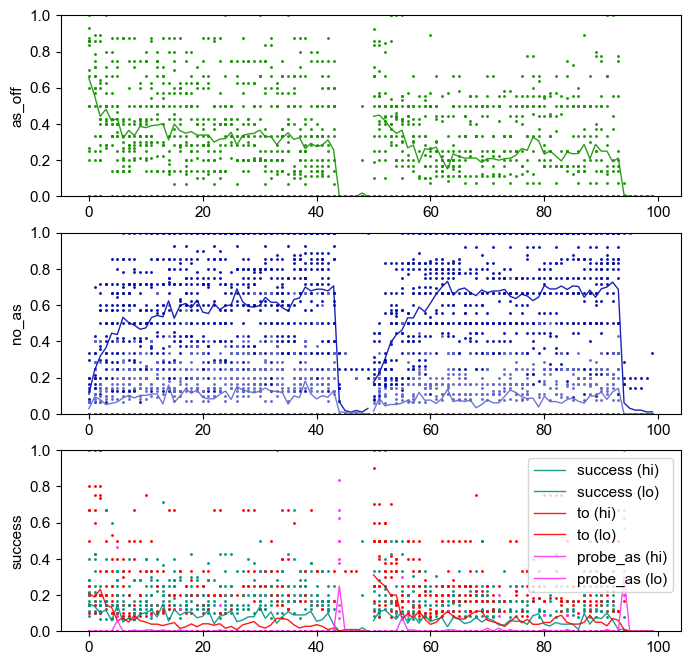

In [37]:
norm = False
total_outcomes = None
total_success = None
total_probe = None
outcome_dict = defaultdict(dict)

outcome_dict = {}
for dfc in reversed(sinq2.df.index):
# for dfc in reversed(sinq2.df.loc[sinq2.df['blue_toggle_fraction']<.8].index):
# for dfc in reversed(sinq2.df.loc[sinq2.df['blue_toggle_fraction']>.8].index):
# for dfc in ['250304_F3_C1','250425_F1_C1']:
    export_path = f'./Figure2/{dfc}/exports'
    pklpat = f'{export_path}/folded_outcome_counts_{dfc}.pkl'
    file_path = glob.glob(pklpat)
    if file_path:
        file_path = file_path[0]
        print(file_path)

    outcome_dict[dfc] = pd.read_pickle(file_path)

    if total_outcomes is None:
        total_outcomes = outcome_dict[dfc].copy()
    else:
        total_outcomes = total_outcomes.add(outcome_dict[dfc], fill_value=0)

norm = True
plt.close('all')
fig = Figure(figsize=(8,8))
lines = defaultdict(dict)

colors = {'hi': '#1f77b4', 
        'lo': '#d62728'}
colors = {'as_off': "#169400", 
            'no_as': "#000cad",
            'no_as_mv': "#6068cb",
            'success': "#009480",
            'to': "#FF0000",
            'probe_as': "#FF30FC",
        }

hi_x = total_outcomes.xs('hi', level='pyasState').index
x = {'hi': hi_x,
    'lo': total_outcomes.xs('lo', level='pyasState').index + hi_x[-1] + 1}

outcome_to_ax = {'as_off':1,
                'no_as':2,
                'no_as_mv':2,
                'success':3,
                'to':3,
                'probe_as':3,}

ax_ids = sorted(set(outcome_to_ax.values()))
ax_id_to_ax = {}
for i, ax_id in enumerate(ax_ids, start=1):
    ax_id_to_ax[ax_id] = fig.add_subplot(len(ax_ids), 1, i)

# for dfc in reversed(sinq2.df.index):
for dfc in outcome_dict.keys():
    for outcome in outcome_to_ax.keys():
        for st in ['hi','lo']:
            outcomes = outcome_dict[dfc]
            ax = ax_id_to_ax[outcome_to_ax[outcome]]
            hi_y = outcomes.xs(st, level='pyasState').get(outcome)
            if norm:
                hi_y = hi_y / outcomes.xs(st, level='pyasState').get('max_cnts')

            ax.scatter(
                        x[st], hi_y, marker='.',s=5, alpha=0.9, c=colors[outcome]
                    )
            if norm:
                ax.set_ylim([0, 1])
            else:
                ax.set_ylim([0, np.max(outcomes.xs(st, level='pyasState').get('max_cnts'))])


for outcome in outcome_to_ax.keys():
    for st in ['hi','lo']:
        ax = ax_id_to_ax[outcome_to_ax[outcome]]
        hi_y = total_outcomes.xs(st, level='pyasState').get(outcome)
        if norm:
            hi_y = hi_y / total_outcomes.xs(st, level='pyasState').get('max_cnts')

        lines[outcome][st], = ax.plot(
                    x[st], hi_y, label=f'{outcome} ({st})', linewidth=1, alpha=0.9, color=colors[outcome]
                )
        if norm:
            ax.set_ylim([0, 1])
        else:
            ax.set_ylim([0, np.max(total_outcomes.xs(st, level='pyasState').get('max_cnts'))])

ax_id_to_ax[1].set_ylabel('as_off')
ax_id_to_ax[2].set_ylabel('no_as')
ax_id_to_ax[3].set_ylabel('success')
ax_id_to_ax[3].legend()
fig.savefig(f'./Figure2/outcomes_over_blocks_all.svg',format='svg')
# fig.savefig(f'./Figure2/outcomes_over_blocks_red.svg',format='svg')
# fig.savefig(f'./Figure2/outcomes_over_blocks_blue.svg',format='svg')
display(fig)

## Get the mean of each category of the last 30 trials for each fly

./Figure2/250925_F1_C1/exports/folded_outcome_counts_250925_F1_C1.pkl
./Figure2/250924_F2_C1/exports/folded_outcome_counts_250924_F2_C1.pkl
./Figure2/250924_F1_C1/exports/folded_outcome_counts_250924_F1_C1.pkl
./Figure2/250923_F2_C1/exports/folded_outcome_counts_250923_F2_C1.pkl
./Figure2/250923_F1_C1/exports/folded_outcome_counts_250923_F1_C1.pkl
./Figure2/250514_F1_C1/exports/folded_outcome_counts_250514_F1_C1.pkl
./Figure2/250506_F2_C1/exports/folded_outcome_counts_250506_F2_C1.pkl
./Figure2/250425_F1_C1/exports/folded_outcome_counts_250425_F1_C1.pkl
./Figure2/250304_F3_C1/exports/folded_outcome_counts_250304_F3_C1.pkl
./Figure2/250228_F2_C1/exports/folded_outcome_counts_250228_F2_C1.pkl
./Figure2/250227_F3_C1/exports/folded_outcome_counts_250227_F3_C1.pkl
./Figure2/250227_F2_C1/exports/folded_outcome_counts_250227_F2_C1.pkl
./Figure2/210917_F2_C1/exports/folded_outcome_counts_210917_F2_C1.pkl
./Figure2/210915_F1_C1/exports/folded_outcome_counts_210915_F1_C1.pkl
./Figure2/210903_F3_

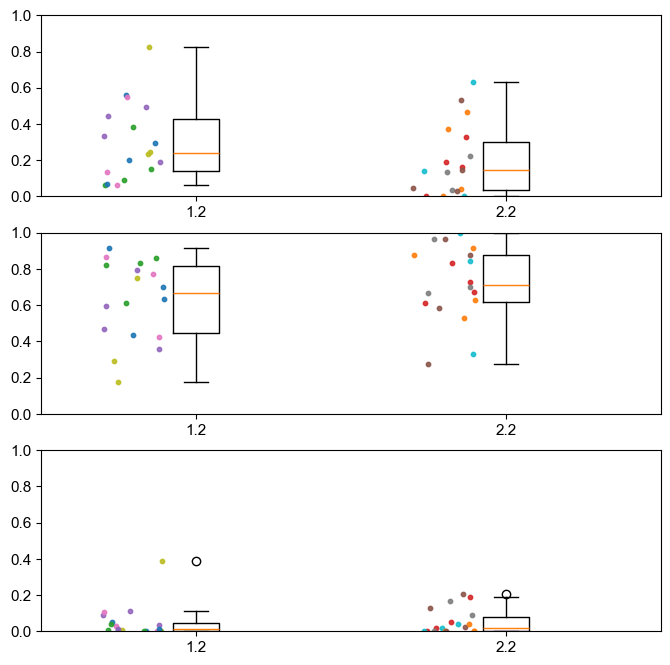

In [63]:
import random

outcome_dict = {}
plt.close('all')
fig = Figure(figsize=(8,8))
fly_means = defaultdict(dict)
# fly_means = defaultdict(lambda: defaultdict(dict))

outcome_to_ax = {'as_off':1,
                'no_as':2,
                # 'no_as_mv':2,
                # 'success':3,
                'to':3,
                # 'probe_as':3,
                }

for dfc in reversed(sinq2.df.index):
# for dfc in ['250304_F3_C1']:
    export_path = f'./Figure2/{dfc}/exports'
    pklpat = f'{export_path}/folded_outcome_counts_{dfc}.pkl'
    file_path = glob.glob(pklpat)
    if file_path:
        file_path = file_path[0]
        print(file_path)

    outcome_dict[dfc] = pd.read_pickle(file_path)
    for outcome in outcome_to_ax.keys():
        fly_means[outcome]['hi'] = []
        fly_means[outcome]['lo'] = []


ax_ids = sorted(set(outcome_to_ax.values()))
ax_id_to_ax = {}
for i, ax_id in enumerate(ax_ids, start=1):
    ax_id_to_ax[ax_id] = fig.add_subplot(len(ax_ids), 1, i)
    ax_id_to_ax[ax_id].set_ylim([0, 1])

# for dfc in reversed(sinq2.df.index):
for dfc in outcome_dict.keys():
    outcomes = outcome_dict[dfc]
    for st in ['hi','lo']:
        last30 = outcomes.loc[(st,[i for i in range(20,44)]),:]
        for outcome in outcome_to_ax.keys():
            ax = ax_id_to_ax[outcome_to_ax[outcome]]
            hi_y = last30.get(outcome) / last30.xs(st, level='pyasState').get('max_cnts')
            hi_y = hi_y.mean()
            x = 1 if st=='hi' else 2
            x = x +random.uniform(-.1, .1)
            ax.scatter(x, hi_y, marker='o',s=10, alpha=0.9,label=dfc)

            fly_means[outcome][st].append(hi_y)

for outcome in fly_means.keys():
    out_means = fly_means[outcome]
    for st in out_means.keys():
        ax = ax_id_to_ax[outcome_to_ax[outcome]]
        x = 1 if st=='hi' else 2
        x = x + .2
        st_means = out_means[st]
        print(st_means)
        ax.boxplot(st_means, vert=True, positions=[x])
        # ax.boxplot(st_means)

display(fig)

In [58]:
fly_means

defaultdict(dict,
            {'as_off': {'hi': [np.float64(0.5625),
               np.float64(0.15231481481481482),
               np.float64(0.4910714285714286),
               np.float64(0.548611111111111),
               np.float64(0.8229166666666666),
               np.float64(0.29583333333333334),
               np.float64(0.0625),
               np.float64(0.33229166666666665),
               np.float64(0.1369047619047619),
               np.float64(0.24503968253968253),
               np.float64(0.20000000000000004),
               np.float64(0.38095238095238093),
               np.float64(0.4416666666666667),
               np.float64(0.0625),
               np.float64(0.23611111111111108),
               np.float64(0.06944444444444443),
               np.float64(0.09166666666666667),
               np.float64(0.19047619047619047)],
              'lo': [np.float64(0.3726851851851851),
               np.float64(0.1622850529100529),
               np.float64(0.5321127946127947),

In [43]:
outcomes.loc[('hi',[i for i in range(20,44)]),:].mean()

as_outcome
no_as_no_mv     11.583333
no_as_mv         0.500000
as_off           1.916667
as_off_late      0.083333
timeout_fail     0.000000
timeout          0.000000
probe            0.000000
rest             0.000000
info             0.000000
max_cnts        14.000000
no_as           12.083333
to               0.000000
success          0.583333
probe_as         0.000000
dtype: float64

# Are successes more likely after both edges have been sampled?

# Are AS-off trials similar to success in their distributions of movement vigor?

## First ask if AS-off trials reach a steady state?

# Show probe trials

In [ ]:
print(T.df.loc[T.df['as_outcome']=='probe',['as_duration',"prestim_v_rms","prestim_holding_cost"]])

In [ ]:
fig = Figure(figsize = (8,6),dpi=200)
ax = fig.add_subplot(1,1,1)
T.plot_some_probe_groups(T.df.loc[343:348,:].index,ax=ax,force_pos=True)
print(T.df.loc[343:348,"as_duration"])
fig

# How much cummulative punishment to flies receive?

In [77]:
import matplotlib.patches as patches
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults
mpl.rcParams['pdf.fonttype'] = 42         # embed fonts as text, not paths
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVG
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 11

def cumulative_punishment(T:Table = None,cpdf = None, fig = None, ax = None, dfc = None, fig_dir:str = './Figure2',dur_v_trial_flag = False):
    output_directory = None

    if not T is None:
        fig = Figure(figsize=(6, 6), dpi=200)
        canvas = FigureCanvas(fig)
        ax = fig.add_subplot(111)

        cpdf = T.df[['pyasState','pyasXPosition','pyasWidth','probeZero','as_duration','on_target','time_on_target','op_cnd_blocks','total_duration']].copy()
        cpdf['cum_pun'] = cpdf['as_duration'].cumsum()
        cpdf['cum_dur'] = cpdf['total_duration'].cumsum()
        dfc = T.dfc
        output_directory = f'{fig_dir}/{T.dfc}'
        export_path = f'{fig_dir}/{T.dfc}/exports'

    rocket_cmap = sns.color_palette("rocket", as_cmap=True)

    cmin = 10
    cmax = -500

    _force_clrs = [
        (np.float64(0.95447591), np.float64(0.47082238), np.float64(0.32310953)),
        (np.float64(0.7965014), np.float64(0.10506637), np.float64(0.31063031)),
        ]
    if not dur_v_trial_flag:
        for ocb in cpdf['op_cnd_blocks'].unique():
            # print(ocb)
            T_rows = cpdf[cpdf['op_cnd_blocks']==ocb]
            
            tr_min = T_rows.index.min()
            tr_max = T_rows.index.max()
            width = tr_max-tr_min
            cum_block_min = T_rows.loc[tr_min,'cum_pun']
            cum_block_max = T_rows.loc[tr_max,'cum_pun']
            height = cum_block_max-cum_block_min

            # target patches
            tgt_clr = _force_clrs[0] if T_rows.loc[tr_min,'pyasState']=='lo' else _force_clrs[1]
            rect = patches.Rectangle(
                    (tr_min,cum_block_min),        # Bottom-left corner of the rectangle
                    width,           # Width (covers the specified rows)
                    height, # Height (covers all categories)    
                    linewidth=0,                        
                    edgecolor='none',
                    facecolor=tgt_clr,
                    alpha=.2
                )
            ax.add_patch(rect)

    y = cpdf['cum_pun']
    if dur_v_trial_flag:
        x = cpdf['cum_dur']/60
        x_label = 'Experiment duration (min)'
    else:
        x = cpdf.index
        x_label = 'Trial number'

    if not T is None:
        ax.plot(x,y,color='black',label=dfc)
    else:
        ax.plot(x,y,label=dfc)

    # ax.plot(T.df.index,T.df['on_target'].cumsum())
    # ax.plot(T.df.index,T.df['time_on_target'].cumsum())
    ax.set_xlabel(x_label)
    ax.set_ylabel("Cumulative punishment (s)")
    ax.set_title(f'Cumulative punishment')
    
    if not output_directory is None:    
        # fig.savefig(f'{output_directory}/cumulative_punishment{T.dfc}.svg',format='svg')
        fig.savefig(f'{output_directory}/cumulative_punishment{T.dfc}.png',format='png')
        cpdf.to_pickle(path=f'{export_path}/cumulative_punishment_{T.dfc}.pkl')

    return fig,ax



In [73]:
for dfc in sinq2.df.index:
    T = sinq2.restore_table(dayflycell=dfc)
    T.extract_trial_properties()
    T.extract_trial_properties(prop_list = ['on_target'])
    T.extract_trial_properties(prop_list = ['time_on_target'])

    fig,ax = cumulative_punishment(T)
    sinq2.drop_tables()

Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\210302\\210302_F1_C2\\LEDFlashWithPiezoCueControl_210302_F1_C2_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=239, 210302_F1_C2, dT=10.44668, ex=True), Trial(trial=355, 210302_F1_C2, dT=14.47674, ex=True), Trial(trial=474, 210302_F1_C2, dT=8.9779, ex=True), Trial(trial=602, 210302_F1_C2, dT=8.9568, ex=True)]
Getting all meta keys
['as_outcome', 'fiberLED', 'filterLED', 'filtercube_status', 'probeZero', 'pyasState', 'pyasWidth', 'pyasXPosition']
Found 2 target positions - Counter({('lo', 650.0, -180.0, 80.0): 403, ('hi', 650.0, -280.0, 80.0): 397})
Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\210405\\210405_F1_C1\\LEDFlashWithPiezoCueControl_210405_F1_C1_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=101, 210405_F1_C1, dT=7.98784, ex=True), Trial(trial=190, 210405_F1_C1, dT=6.79924, ex=True), Trial(trial=312, 210405_F1_C1, dT=7.09124, ex=True), Trial(trial=631, 210405_F1_C1, dT=6.0

./Figure2/210302_F1_C2/exports/cumulative_punishment_210302_F1_C2.pkl
./Figure2/210405_F1_C1/exports/cumulative_punishment_210405_F1_C1.pkl
./Figure2/210604_F1_C1/exports/cumulative_punishment_210604_F1_C1.pkl
./Figure2/210903_F3_C1/exports/cumulative_punishment_210903_F3_C1.pkl
./Figure2/210915_F1_C1/exports/cumulative_punishment_210915_F1_C1.pkl
./Figure2/210917_F2_C1/exports/cumulative_punishment_210917_F2_C1.pkl
./Figure2/250227_F2_C1/exports/cumulative_punishment_250227_F2_C1.pkl
./Figure2/250227_F3_C1/exports/cumulative_punishment_250227_F3_C1.pkl
./Figure2/250228_F2_C1/exports/cumulative_punishment_250228_F2_C1.pkl
./Figure2/250304_F3_C1/exports/cumulative_punishment_250304_F3_C1.pkl
./Figure2/250425_F1_C1/exports/cumulative_punishment_250425_F1_C1.pkl
./Figure2/250506_F2_C1/exports/cumulative_punishment_250506_F2_C1.pkl
./Figure2/250514_F1_C1/exports/cumulative_punishment_250514_F1_C1.pkl
./Figure2/250923_F1_C1/exports/cumulative_punishment_250923_F1_C1.pkl
./Figure2/250923_F2_

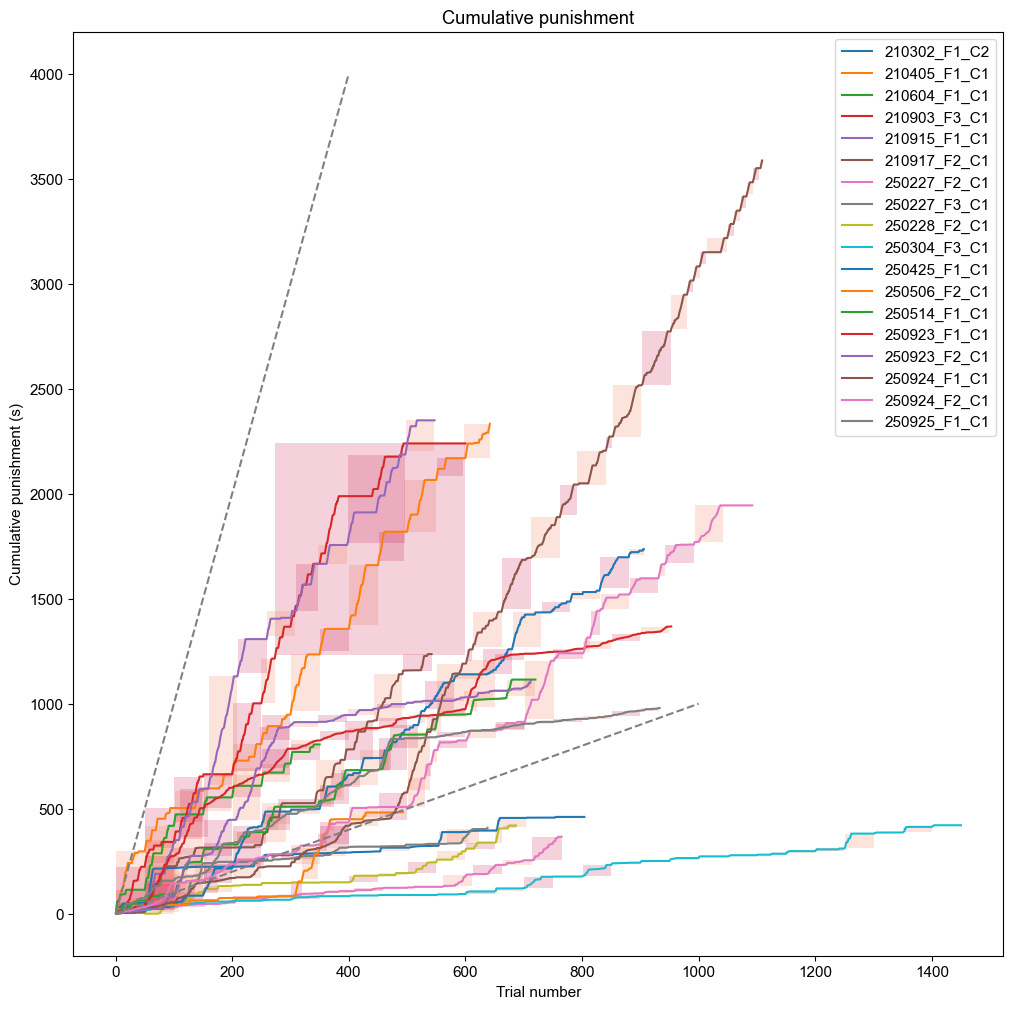

In [79]:
# Now load and plot the plots together
cpdf = defaultdict(dict)

ftrfig = Figure(figsize=(12,12))
# plt.figure(figsize=(5,5))
ftrax = ftrfig.add_subplot(1, 1, 1)
dur_v_trial_flag = False

for dfc in sinq2.df.index:
    export_path = f'./Figure2/{dfc}/exports'
    pklpat = f'{export_path}/cumulative_punishment_{dfc}.pkl'
    file_path = glob.glob(pklpat)
    if file_path:
        file_path = file_path[0]
        print(file_path)

    cpdf[dfc] = pd.read_pickle(file_path)
    # cpdf[dfc]['cum_dur'] = cpdf[dfc]['total_duration'].cumsum()
    ftrfig,ftrax = cumulative_punishment(cpdf=cpdf[dfc],fig = ftrfig,ax=ftrax,dur_v_trial_flag=dur_v_trial_flag,dfc=dfc)

if not dur_v_trial_flag:
    x = [0,  400]
    y = [0, 400*10]
    ftrax.plot(x,y,ls='--',color='gray')

    x = [0,  1000]
    y = [0, 1000*1]
    ftrax.plot(x,y,ls='--',color='gray')

ftrax.legend()
display(ftrfig)
ftrfig.savefig('./Figure2/cumulative_punishment_over_trials_all_flies_trials.svg')


## Select a couple punishment schedules to replay to new flies

Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\250924\\250924_F2_C1\\LEDFlashTriggerPiezoControl_250924_F2_C1_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=962, 250924_F2_C1, dT=7.60812, ex=True), Trial(trial=964, 250924_F2_C1, dT=9.30398, ex=True), Trial(trial=965, 250924_F2_C1, dT=8.81784, ex=True), Trial(trial=967, 250924_F2_C1, dT=9.98546, ex=True), Trial(trial=968, 250924_F2_C1, dT=12.89248, ex=True), Trial(trial=971, 250924_F2_C1, dT=7.8273, ex=True), Trial(trial=973, 250924_F2_C1, dT=8.98408, ex=True), Trial(trial=974, 250924_F2_C1, dT=8.75678, ex=True), Trial(trial=975, 250924_F2_C1, dT=7.84768, ex=True), Trial(trial=980, 250924_F2_C1, dT=9.5419, ex=True), Trial(trial=981, 250924_F2_C1, dT=10.71484, ex=True), Trial(trial=984, 250924_F2_C1, dT=8.38268, ex=True), Trial(trial=994, 250924_F2_C1, dT=9.08194, ex=True), Trial(trial=995, 250924_F2_C1, dT=7.99636, ex=True), Trial(trial=997, 250924_F2_C1, dT=9.28016, ex=True), Trial(trial=998, 250924_F2_C1, 

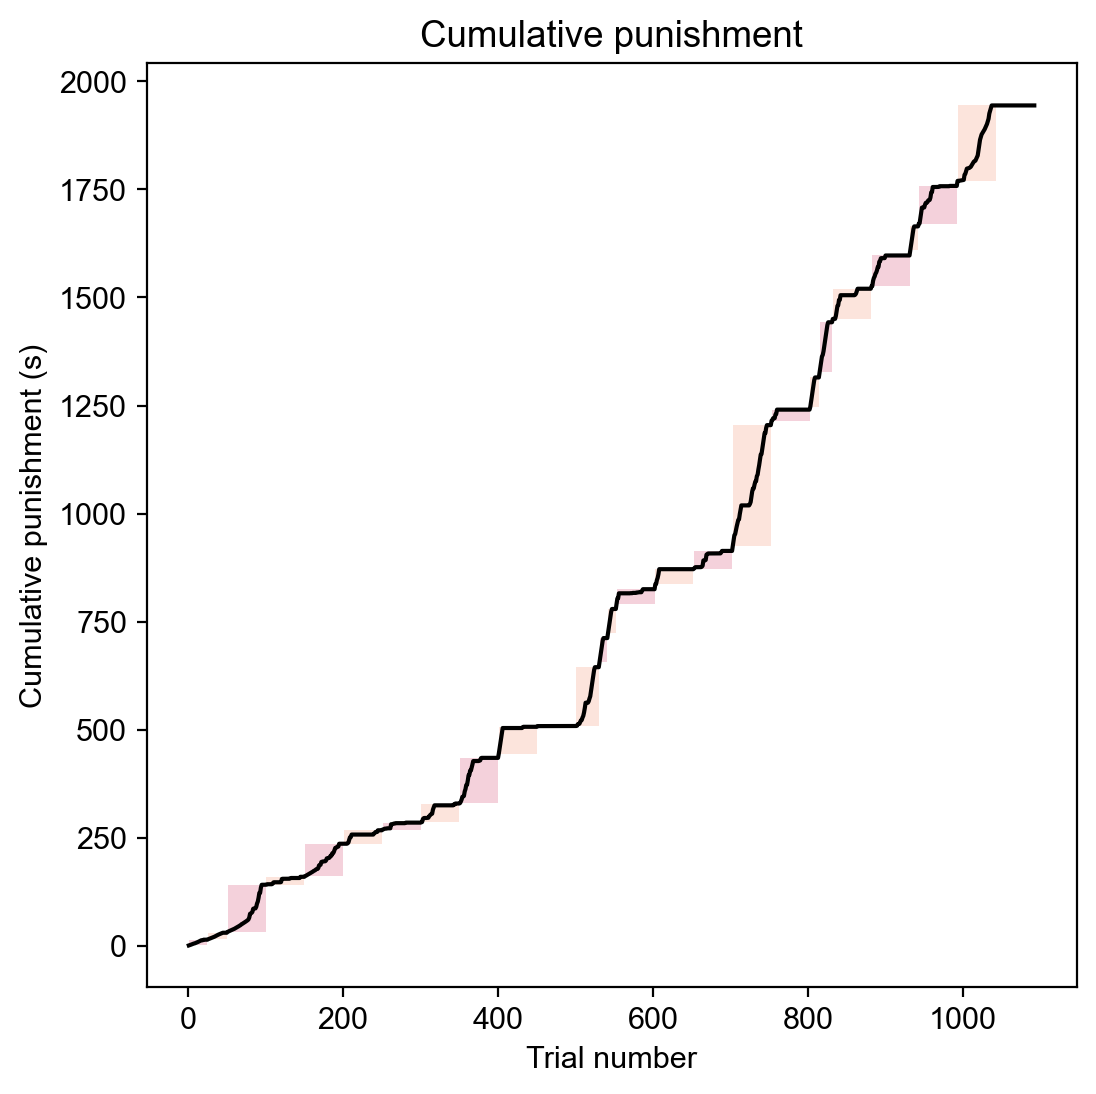

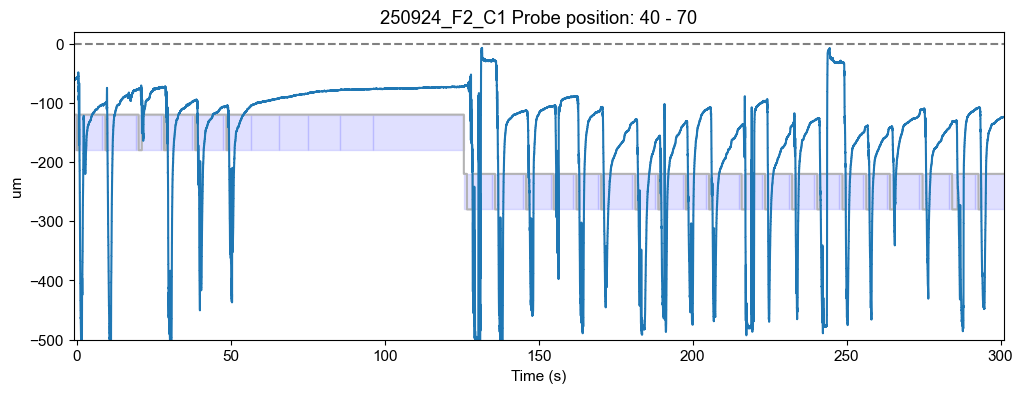

Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\250228\\250228_F2_C1\\LEDFlashTriggerPiezoControl_250228_F2_C1_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=688, 250228_F2_C1, dT=9.37912, ex=True), Trial(trial=689, 250228_F2_C1, dT=7.27826, ex=True), Trial(trial=690, 250228_F2_C1, dT=7.93964, ex=True), Trial(trial=691, 250228_F2_C1, dT=10.04582, ex=True), Trial(trial=692, 250228_F2_C1, dT=9.99308, ex=True), Trial(trial=693, 250228_F2_C1, dT=10.40342, ex=True), Trial(trial=694, 250228_F2_C1, dT=8.27568, ex=True), Trial(trial=695, 250228_F2_C1, dT=9.29316, ex=True), Trial(trial=696, 250228_F2_C1, dT=11.06214, ex=True), Trial(trial=697, 250228_F2_C1, dT=9.42474, ex=True), Trial(trial=698, 250228_F2_C1, dT=8.1925, ex=True), Trial(trial=699, 250228_F2_C1, dT=10.14614, ex=True), Trial(trial=700, 250228_F2_C1, dT=9.19616, ex=True), Trial(trial=701, 250228_F2_C1, dT=8.62874, ex=True), Trial(trial=702, 250228_F2_C1, dT=10.30976, ex=True), Trial(trial=703, 250228_F2_

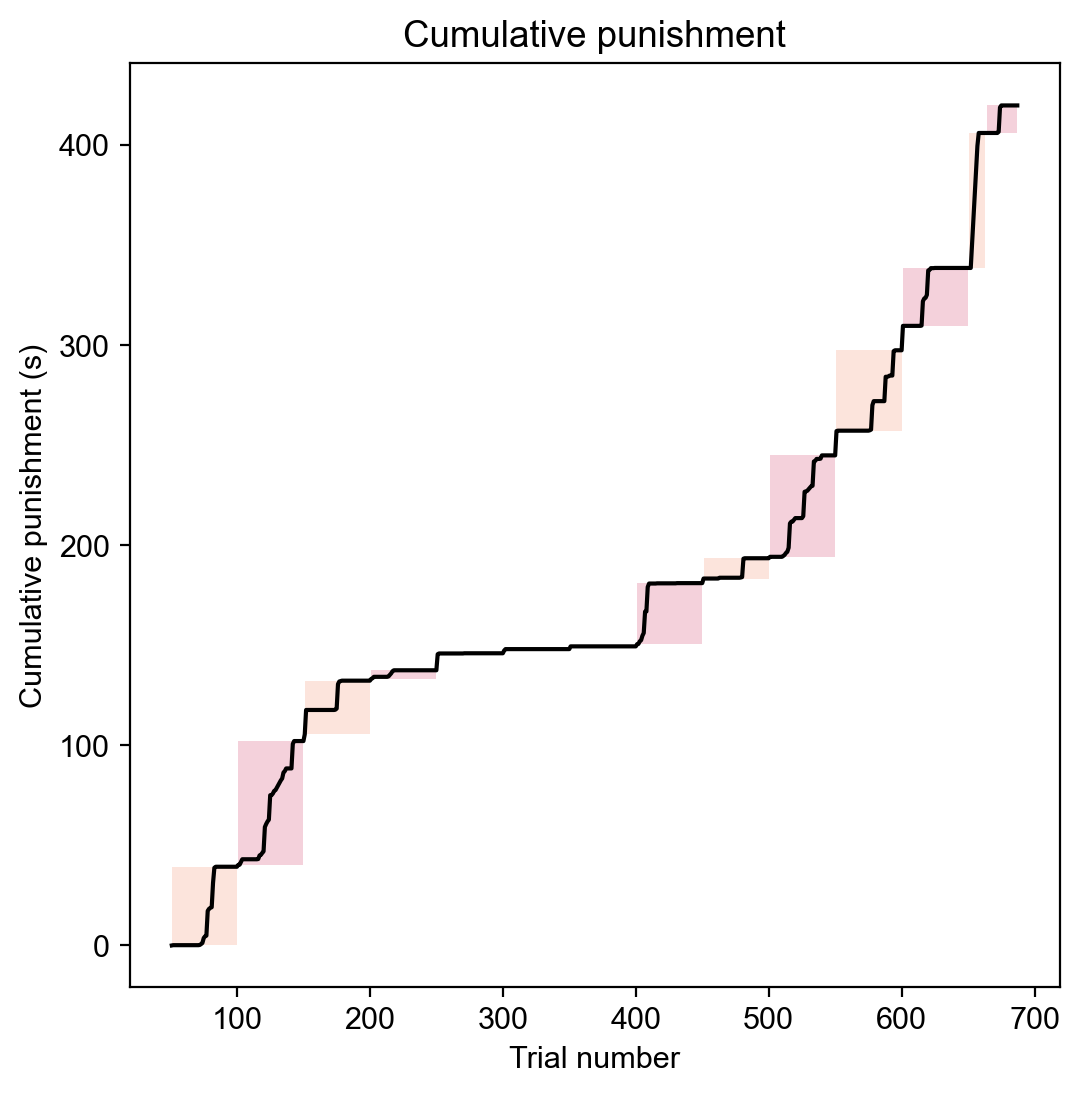

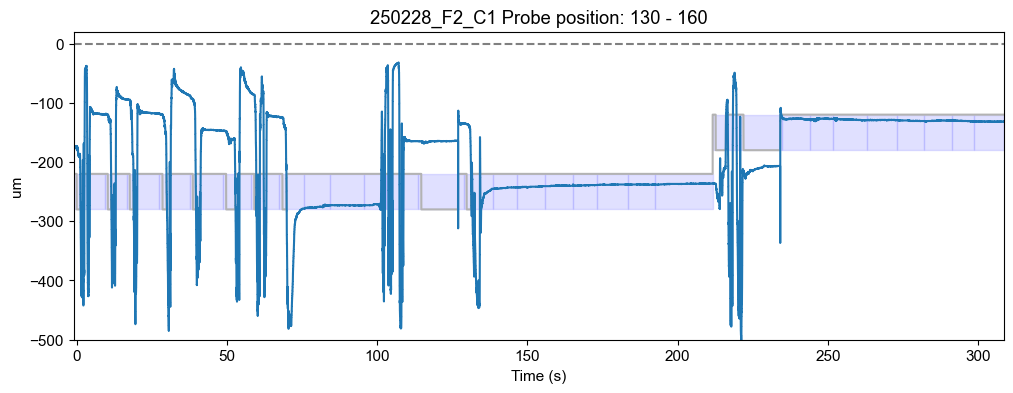

In [83]:
# for dfc in sinq2.df.index:
trofinterestdict = { # '210302_F1_C2':[40],  # big step early on
                    # '250304_F3_C1':[[700, 1270, 825]],   # too good
                    '250924_F2_C1':[40], # consistent punishment
                    '250228_F2_C1':[130]
                    }

for dfc in trofinterestdict.keys():  #'210302_F1_C2'
    T = sinq2.restore_table(dayflycell=dfc)
    T.extract_trial_properties()
    T.extract_trial_properties(prop_list = ['on_target'])
    T.extract_trial_properties(prop_list = ['time_on_target'])

    fig,ax = cumulative_punishment(T,dur_v_trial_flag=False)
    display(fig)

    tr_0 = trofinterestdict[dfc]
    ftrfig = Figure(figsize=(12,4))
    ftrax = ftrfig.add_subplot(1, 1, 1)
    for tr in tr_0:
        ftrax = T.plot_some_probe_groups(index=T.df.loc[tr:tr+30].index,ax=ftrax,savefig=False,from_zero=True,format='svg')

        display(ftrfig)
        ftrfig.savefig(f'./Figure2/{T.dfc}/cumulative_punishment_{T.dfc}_{tr}_{tr+30}.png')

    sinq2.drop_tables()

In [ ]:
cpdf = pd.read_pickle('./Figure2/250924_F2_C1/exports/cumulative_punishment_210302_F1_C2.pkl')
cpdf

,pyasState,pyasXPosition,pyasWidth,probeZero,as_duration,on_target,time_on_target,op_cnd_blocks,cum_pun
trial_number,,,,,,,,,
1,hi,370.0,80.0,650.0,8.39866,0.000000,0.00000,1,8.39866
2,hi,370.0,80.0,650.0,10.08982,0.000000,0.00000,1,18.48848
3,hi,370.0,80.0,650.0,4.45474,0.315847,3.11308,1,22.94322
4,hi,370.0,80.0,650.0,5.82726,0.691569,15.31404,1,28.77048
5,hi,370.0,80.0,650.0,0.15734,0.881087,7.06096,1,28.92782
...,...,...,...,...,...,...,...,...,...
800,lo,470.0,80.0,650.0,0.00000,1.000000,7.03810,16,461.02042
801,lo,470.0,80.0,650.0,0.00000,1.000000,7.56658,16,461.02042
802,lo,470.0,80.0,650.0,0.00000,0.047752,0.29996,16,461.02042


In [84]:
# In Python
import pandas as pd
import scipy.io as sio
import pickle


pkls = [
        './Figure2/250228_F2_C1/exports/cumulative_punishment_250228_F2_C1.pkl',
        './Figure2/250924_F2_C1/exports/cumulative_punishment_250924_F2_C1.pkl',
        ]

for pk in pkls:
    with open(pk, 'rb') as f:
        data = pickle.load(f)

    # If it's a DataFrame
    if isinstance(data, pd.DataFrame):
        sio.savemat(pk.replace('.pkl', '.mat'), {'data': data.to_dict('list')})
    # or just pickle -> mat for general dict-like objects
    else:
        sio.savemat(pk.replace('.pkl', '.mat'), {'data': data})